<a href="https://colab.research.google.com/github/bio-1220/NLP_study/blob/main/week2_chapter2(84~95).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**데이터셋**

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from datasets import load_dataset

emotions = load_dataset("emotion")

In [ ]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

**데이터셋에서 데이터 프레임 과정**

데이터 확인 및 전처리를 위해, huggingface datasets에서는 보통 안함

In [ ]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


**토큰화**

In [ ]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True)

In [ ]:
emotions.reset_format()
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

**사전 훈련된 모델 로드하기**

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


num_labels = 6
model = (AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**성공 지표 정의하기**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels,preds, average = "weighted")
  acc = accuracy_score(labels,preds)
  return {"accuracy": acc, "f1": f1}

Accuracy
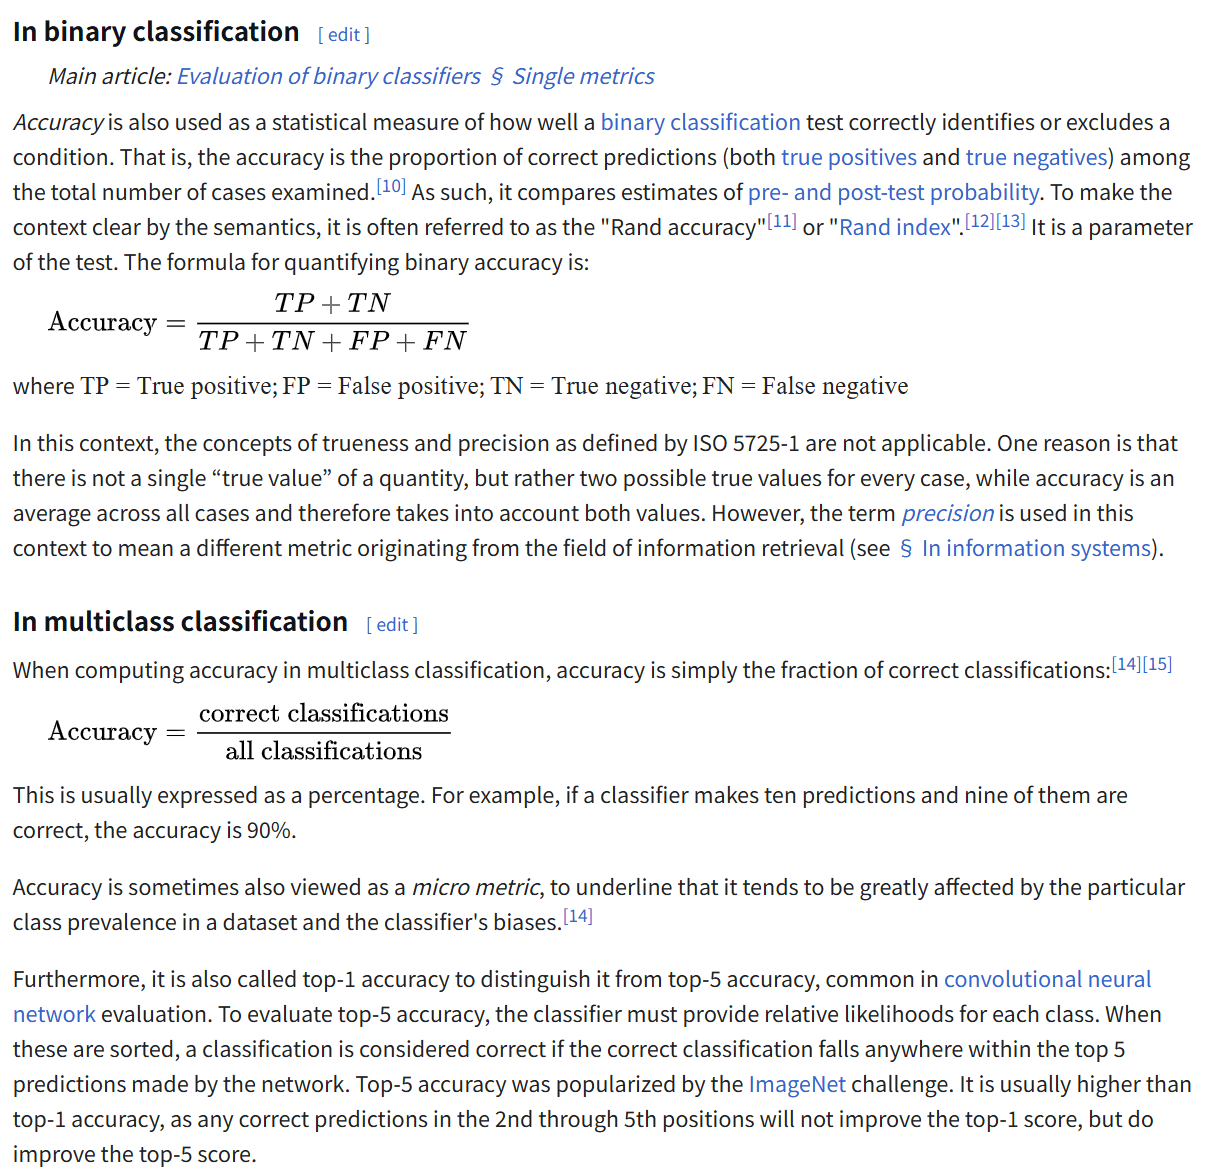

F1_score
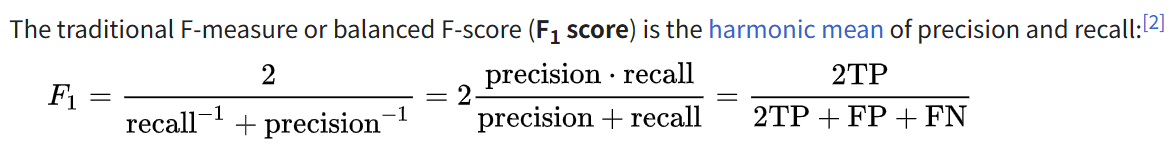


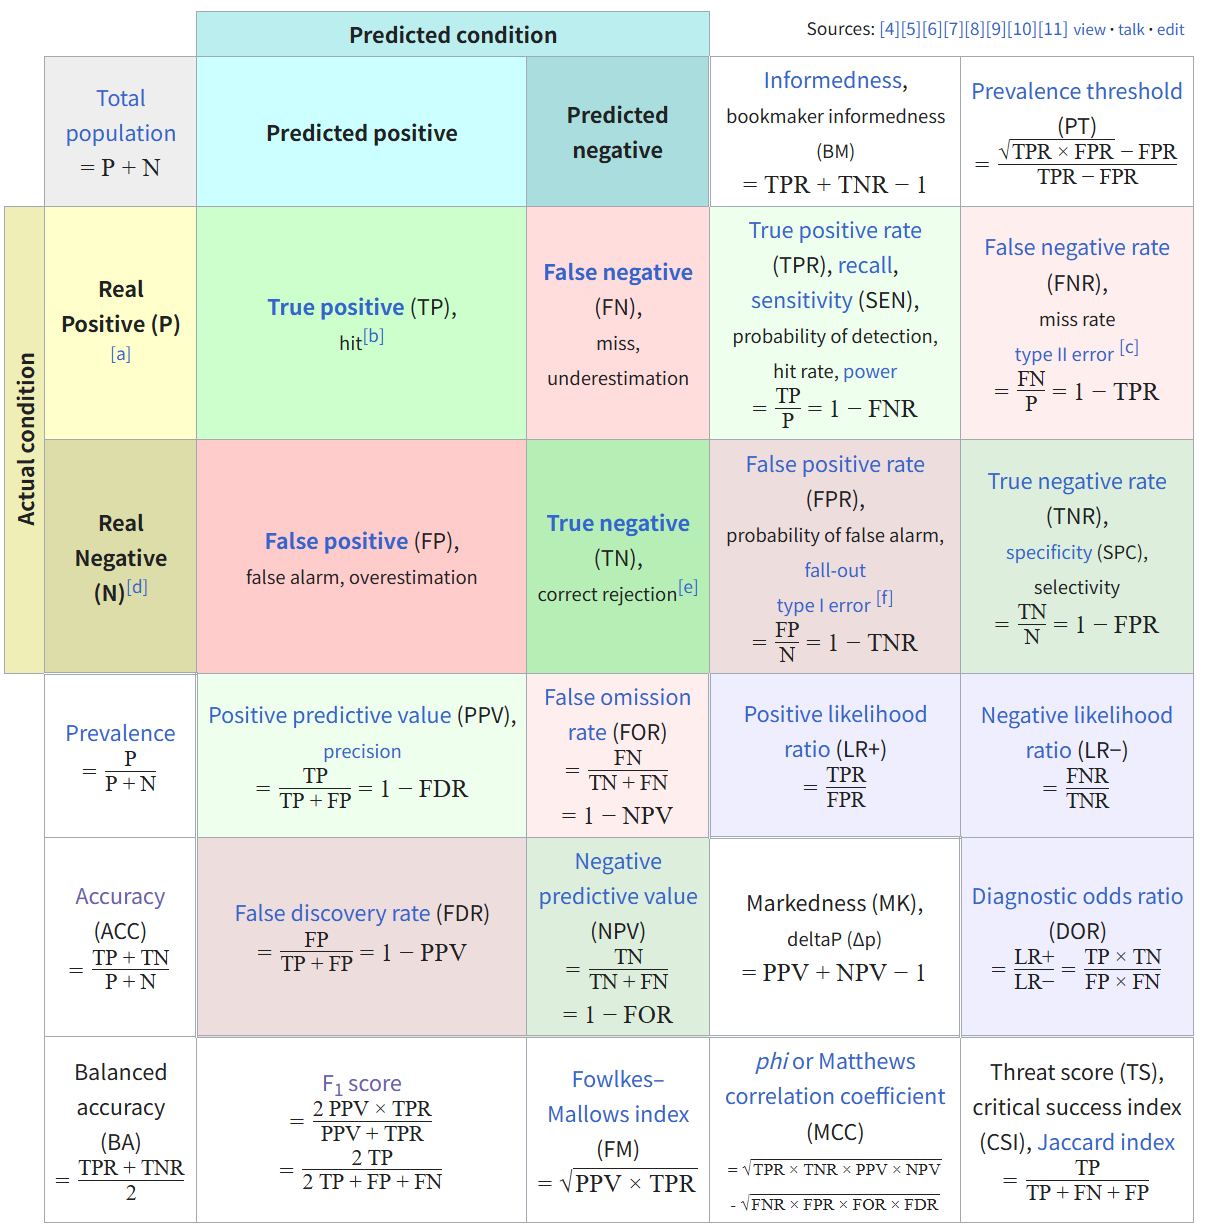

**모델 훈련하기**

In [ ]:
##훈련 파라미터 정의
from transformers import Trainer, TrainingArguments

batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=2,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  eval_strategy="epoch",
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  push_to_hub=True,
                                  save_strategy="epoch",
                                  load_best_model_at_end=True,
                                  log_level="error")

In [ ]:
##Trainer 객체 만들기 및 모델 미세 튜닝
from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"]) # tokenizer 인자 제거
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.543822,0.192249,0.925000,0.925892
2,0.141010,0.134772,0.941000,0.941005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.34241566467285156, metrics={'train_runtime': 13761.4054, 'train_samples_per_second': 2.325, 'train_steps_per_second': 0.036, 'total_flos': 720342861696000.0, 'train_loss': 0.34241566467285156, 'epoch': 2.0})

In [ ]:
##Validation Set
preds_output = trainer.predict(emotions_encoded["validation"])

preds_output.metrics

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 0.1347721666097641,
 'test_accuracy': 0.941,
 'test_f1': 0.9410053878288984,
 'test_runtime': 199.6704,
 'test_samples_per_second': 10.017,
 'test_steps_per_second': 0.16}

In [ ]:
import numpy as np
y_preds = np.argmax(preds_output.predictions, axis=1)
#argmax : 가장 큰 값이 나오도록

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

##confusion matrix 만드는 함수
def plot_confusion_matrix(y_preds, y_true, labels):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

y_true = emotions_encoded["validation"]["label"]
labels = emotions_encoded["train"].features["label"].names

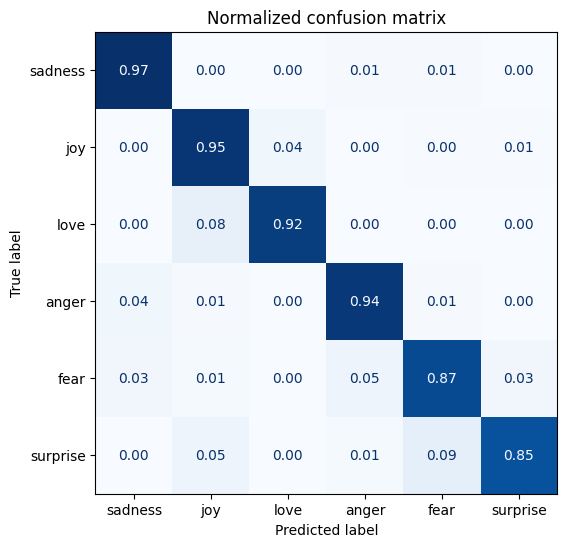

In [ ]:
plot_confusion_matrix(y_preds, y_true, labels)

**오류 분석**

In [ ]:
##손실과 예측 레이블을 반환하는 함수
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
  #모든 입력 텐서를 모델과 같은 장치로 이동
  inputs ={k:v.to(device) for k,v in batch.items()
  if k in tokenizer.model_input_names}

  with torch.no_grad():
    output = model(**inputs)
    pred_label = torch.argmax(output.logits, axis = -1)
    loss = cross_entropy(output.logits, batch["label"].to(device),reduction="none")

  #다른 데이터셋 열과 호환되도록 출력을 cpu로 옮긴다
  return {"loss": loss.cpu().numpy(),"predicted_label" : pred_label.cpu().numpy()}

In [ ]:
#데이터셋을 다시 파이토치 텐서로 변환
emotions_encoded.set_format("torch",columns=["input_ids","attention_mask","label"])

#손실 값 계산
emotions_encoded["validation"] = emotions_encoded["validation"].map(forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
#텍스트,손실,예측레이블,진짜레이블을 모아 DataFrame으로 만든다
emotions_encoded.set_format("pandas")
cols = ["text","label","predicted_label","loss"]
df_test = emotions_encoded["validation"][:][cols]

def label_int2str(label_int):
    return labels[label_int]

df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = df_test["predicted_label"].apply(label_int2str)

In [ ]:
#손실이 가장 높은 샘플
df_test.sort_values("loss",ascending=False).head(10)

,text,label,predicted_label,loss
177,im sure much of the advantage is psychological...,sadness,joy,6.618914
405,i have been feeling extraordinarily indecisive...,fear,joy,6.223820
1509,i guess this is a memoir so it feels like that...,joy,fear,4.989037
1581,i feel stronger clearer but a little annoyed n...,anger,joy,4.831771
1963,i called myself pro life and voted for perry w...,joy,sadness,4.688615
415,im kind of embarrassed about feeling that way ...,love,joy,4.341967
570,i don t mean this to be harsh selfish or uncar...,joy,anger,4.153517
1124,someone acting stupid in public,anger,sadness,3.999122
1683,i had applied for a job and they had assured m...,anger,joy,3.780243
1046,i cant even describe to you what it feels like...,sadness,fear,3.471047


In [ ]:
#손실이 가장 낮은 샘플
df_test.sort_values("loss",ascending=True).head(10)

,text,label,predicted_label,loss
212,i own the brushes are constantly used and i fe...,joy,joy,0.003419
578,i got to christmas feeling positive about the ...,joy,joy,0.003475
1873,i feel practically virtuous this month i have ...,joy,joy,0.003513
1723,i know how much work goes into the creation an...,joy,joy,0.003533
934,i feel a positive responsibility to see this t...,joy,joy,0.003551
260,i am feeling so invigorated and so ready to ke...,joy,joy,0.003554
876,i feel like the cool mom,joy,joy,0.003571
1418,i am a big believer in the phrase that some pe...,joy,joy,0.003572
107,i feel the cool edge of the barrel against my ...,joy,joy,0.003575
1688,i feel very very rich and fulfilled and a part...,joy,joy,0.003576


**모델 저장 및 공유**

In [ ]:
trainer.push_to_hub(commit_message = "Training completed!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...emotion/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...emotion/model.safetensors:  24%|##3       | 63.9MB /  268MB            

CommitInfo(commit_url='https://huggingface.co/bio-1220/distilbert-base-uncased-finetuned-emotion/commit/9a1324a94ddb979dc4b19f8dc09d8ff33eacf3c6', commit_message='Training completed!', commit_description='', oid='9a1324a94ddb979dc4b19f8dc09d8ff33eacf3c6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/bio-1220/distilbert-base-uncased-finetuned-emotion', endpoint='https://huggingface.co', repo_type='model', repo_id='bio-1220/distilbert-base-uncased-finetuned-emotion'), pr_revision=None, pr_num=None)

In [ ]:
from transformers import pipeline

#bio-1220 : 각자 hugginface id
model_id = "bio-1220/distilbert-base-uncased-finetuned-emotion" # Corrected typo
classifier = pipeline("text-classification",model=model_id)

config.json:   0%|          | 0.00/931 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

**Pipeline test**

In [ ]:
custom_tweet ="I saw a movie today and it was really good."
preds = classifier(custom_tweet,top_k=None)

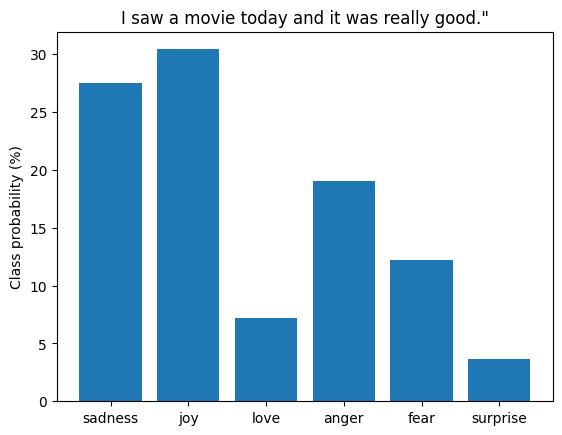

In [ ]:
preds_sorted = sorted(preds,key=lambda d: d['label'])
preds_df = pd.DataFrame(preds_sorted)
plt.bar(labels, 100* preds_df["score"], color='C0')
plt.title(f'{custom_tweet}"')
plt.ylabel("Class probability (%)")
plt.show()

학습이 이상하네;;

train dataset이 좋지 않은듯;;

